# 配套实践 03-01：手工完成一次二维卷积

本练习对应基础篇第 03 章。我们不调用深度学习框架，用 NumPy 明确写出卷积核滑动过程，观察边缘特征、填充、步幅和输出尺寸。依赖：NumPy、Matplotlib；CPU 即可运行。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/03-vision-encoding/" target="_blank">返回课程正文</a>

In [1]:
import numpy as np  # 用规则数组表示图像、卷积核和特征图
import matplotlib.pyplot as plt  # 绘制输入图像与卷积结果
plt.rcParams["figure.dpi"] = 120  # 提高图像在笔记本中的清晰度

## 1. 生成一个容易观察的桌面图像

白色矩形模拟杯子投影，灰色矩形模拟干扰物。这里先使用灰度图，让卷积计算只保留空间维度。

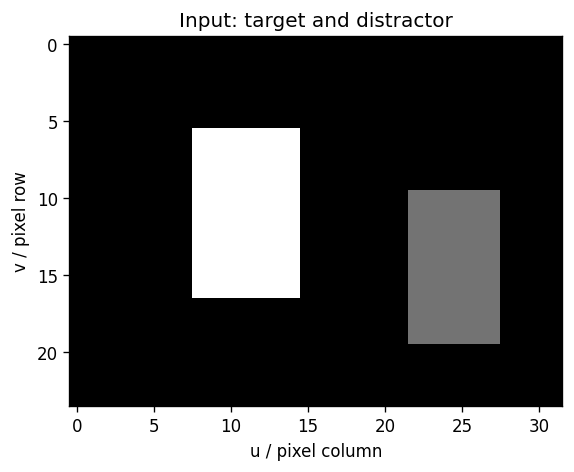

In [2]:
image = np.zeros((24, 32), dtype=np.float64)  # 创建黑色背景的二维图像
image[6:17, 8:15] = 1.0  # 画出亮色目标物体
image[10:20, 22:28] = 0.45  # 画出较暗的干扰物体
fig, ax = plt.subplots(figsize=(6, 4))  # 创建单张输入图的画布
ax.imshow(image, cmap="gray", vmin=0.0, vmax=1.0)  # 按固定灰度范围显示像素
ax.set_title("Input: target and distractor")  # 用无需额外字体的英文短标题说明图片内容
ax.set_xlabel("u / pixel column")  # 标注水平像素坐标
ax.set_ylabel("v / pixel row")  # 标注垂直像素坐标
plt.show()  # 显示输入图像

## 2. 手工实现卷积

函数先填充输入，再按步幅取局部窗口。每个输出值都等于窗口与卷积核逐项相乘后的总和。

In [3]:
def conv2d_single_channel(input_image, kernel, stride=1, padding=0):  # 定义单通道二维卷积
    padded = np.pad(input_image, padding, mode="constant")  # 在边缘补零以控制输出范围
    kernel_height, kernel_width = kernel.shape  # 读取卷积核的高和宽
    output_height = (padded.shape[0] - kernel_height) // stride + 1  # 按公式计算输出高度
    output_width = (padded.shape[1] - kernel_width) // stride + 1  # 按公式计算输出宽度
    output = np.zeros((output_height, output_width), dtype=np.float64)  # 为特征图分配空间
    for out_v in range(output_height):  # 逐行访问输出位置
        for out_u in range(output_width):  # 逐列访问输出位置
            start_v = out_v * stride  # 把输出行换算成输入窗口起点
            start_u = out_u * stride  # 把输出列换算成输入窗口起点
            window = padded[start_v:start_v + kernel_height, start_u:start_u + kernel_width]  # 取出当前局部窗口
            output[out_v, out_u] = np.sum(window * kernel)  # 逐项相乘并求和得到一个特征值
    return output  # 返回完整输出特征图
sobel_vertical = np.array([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]])  # 定义检测竖直边缘的 Sobel 核
feature = conv2d_single_channel(image, sobel_vertical, stride=1, padding=1)  # 对人工图像执行卷积
assert feature.shape == image.shape  # 验证三乘三卷积加一圈填充后尺寸不变
assert np.isfinite(feature).all()  # 验证特征图没有无效数值

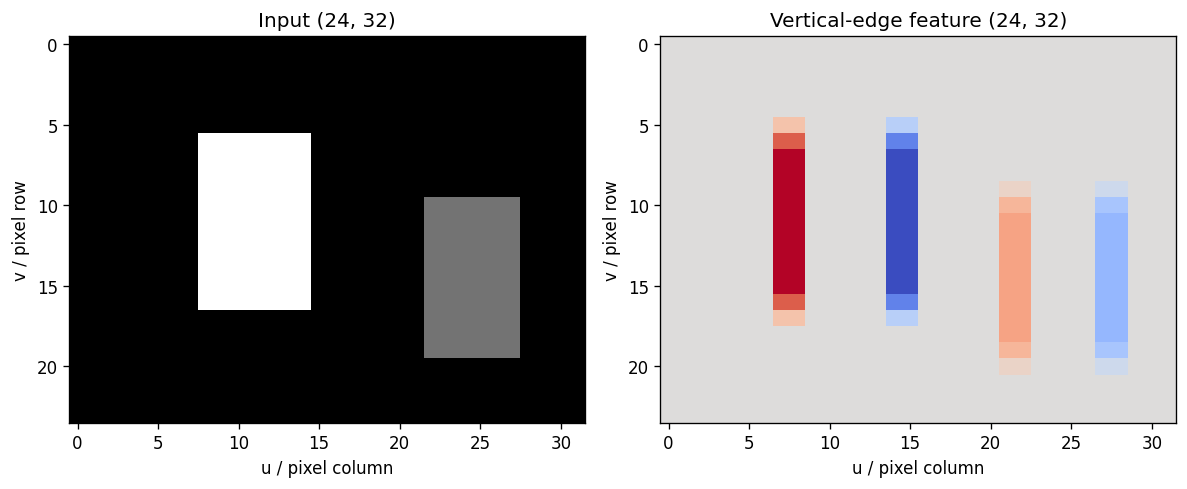

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 创建输入与输出的并排视图
axes[0].imshow(image, cmap="gray", vmin=0.0, vmax=1.0)  # 显示原始灰度图
axes[0].set_title(f"Input {image.shape}")  # 标出输入张量形状
limit = np.max(np.abs(feature))  # 使用正负对称色标便于比较边缘方向
axes[1].imshow(feature, cmap="coolwarm", vmin=-limit, vmax=limit)  # 显示带方向的边缘响应
axes[1].set_title(f"Vertical-edge feature {feature.shape}")  # 标出输出张量形状
for axis in axes:  # 统一设置两个子图的坐标语义
    axis.set_xlabel("u / pixel column")  # 标注横轴为水平位置
    axis.set_ylabel("v / pixel row")  # 标注纵轴为垂直位置
plt.tight_layout()  # 避免标题和坐标标签重叠
plt.show()  # 显示卷积前后结果

**怎样理解结果：** 红蓝响应集中在物体的左右边界，而物体内部接近常数的区域响应很小。卷积核没有直接输出“杯子”，它只提取了一种局部变化。更深层网络会继续组合许多这样的局部特征。

In [5]:
settings = [(1, 0), (1, 1), (2, 1)]  # 依次比较无填充、带填充和步幅二
for stride, padding in settings:  # 遍历三种卷积设置
    result = conv2d_single_channel(image, sobel_vertical, stride=stride, padding=padding)  # 计算当前设置的特征图
    expected_height = (image.shape[0] + 2 * padding - 3) // stride + 1  # 用正文公式计算高度
    expected_width = (image.shape[1] + 2 * padding - 3) // stride + 1  # 用正文公式计算宽度
    assert result.shape == (expected_height, expected_width)  # 检查代码与尺寸公式一致
    print(f"stride={stride}, padding={padding} -> shape={result.shape}")  # 输出参数与实际形状

stride=1, padding=0 -> shape=(22, 30)
stride=1, padding=1 -> shape=(24, 32)
stride=2, padding=1 -> shape=(12, 16)


## 结论与练习

填充决定边缘是否仍有输出位置，步幅决定卷积核每次移动多远。尝试把步幅改为 3，或换成水平 Sobel 核 `[[1,2,1],[0,0,0],[-1,-2,-1]]`，先预测输出形状和响应位置，再运行验证。